# T036 · E(3)-等变图神经网络入门

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Gerrit Großmann, 2022, [建模与仿真教席](https://mosi.uni-saarland.de/people/gerrit/), [NextAID](https://nextaid.cs.uni-saarland.de/) 项目, 萨尔大学


## 本教程的目标

在 **教程 T035** 中，我们学习了如何将图神经网络（GNN）应用于分子。然而，分子图作为分子表示存在一个内在缺陷：它们忽略了至关重要的 3D 信息。本教程希望弥合这一差距，并介绍基于分子的 3D 点云表示来构建 GNN 的基本概念。

具体来说，我们将：

1. 讨论为什么基于图的分子表示是有限的，以及为什么 3D 信息如此重要。
2. 讨论数学框架（等变性和不变性），该框架使我们能够以一种有原则的方式合并 3D 信息。
3. 在 QM9 数据集上实现 E(3)-不变 GNN（EGNN），以预测分子的空间范围。

最后，我们希望你能确信，在数据可用的情况下，将 3D 信息纳入你的模型中是有价值的。


### _理论_ 部分内容

* 为什么需要 3D 坐标？
* 分子作为点云：数学背景
* 欧几里得空间中的等变性和不变性以及我们为什么关注
* 如何构建 E(n)-不变和等变模型
* 关于 E(n)-不变 GNN（EGNN）的详细说明
* QM9 数据集


### _实践_ 部分内容

* 点云可视化
* 设置并检查 QM9 数据集
    * 预处理
    * 原子序数分布和点云大小
    * 数据拆分，回归目标分布
* 模型实现
    * 简单的"朴素欧几里得"GNN
    * 示例：简单 GNN 不是 E(3)-不变的
    * EGNN 模型
    * 示例：EGNN 是 E(3)-不变的
* 训练和评估
    * 训练 EGNN
    * 训练简单 GNN
    * 对比评估


### 参考文献

**本教程中使用的论文和文章**

* *E(n) Equivariant Graph Neural Networks*, Satorras et al., 2021, [[arXiv:2102.09844]](https://arxiv.org/abs/2102.09844)
* *Geometric Deep Learning on Molecular Representations*, Atz et al., 2021, [[Nature Machine Intelligence]](https://www.nature.com/articles/s42256-021-00418-8)
* *Neural Message Passing for Quantum Chemistry*, Gilmer at al., 2017, [[arXiv:1704.01212]](https://arxiv.org/abs/1704.01212)
* *Learning 3D Representations of Molecular Chirality with Invariance to Bond Rotations*, Großmann et al., 2022, [[OpenReview]](https://openreview.net/forum?id=hm2tNDdgaFK)

**等变性和不变性方面的其他优秀资源**

* *A Practical Guide to Group Equivariant Deep Learning*, [[arXiv:2304.06802]](https://arxiv.org/abs/2304.06802)
* *3D Graph Neural Networks for Molecular Property Prediction* (Webinar), [[YouTube]](https://www.youtube.com/watch?v=0gz64KcJsMw)
* *Geometric Deep Learning: The Erlangen Programme of ML*, [[YouTube]](https://www.youtube.com/watch?v=w6Pw4MOzMvo)

**本教程中使用的软件包**

* PyTorch Geometric, [[Website]](https://pytorch-geometric.readthedocs.io/)
* PyTorch, [[Website]](https://pytorch.org/)
* NGLView, [[Website]](http://nglviewer.org/nglview/latest/)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 36
    %pip uninstall teachopencadd -y -q
    %pip install torch torch_geometric torch-scatter numpy matplotlib tqdm pandas notebook nbformat jupyterlab-widgets

## 理论


### 为什么需要 3D 坐标？

在 **教程 T033** 中，我们了解到分子有几种不同的表示方法。在 **教程 T035** 中，我们使用 **分子图** 作为 GNN 的输入。但正如我们在 **教程 T033** 中了解到的，分子图无法唯一地表征分子。回顾一下，2-丁醇（以及其他手性分子）的两种对映体具有相同的分子图（和相同的 SMILES），因此当仅使用 2D 分子图作为输入时，它们对于 GNN 来说是难以区分的。

但分子的性质（如结合选择性）可能取决于其构型（即特定对映体）。在我们的分子性质预测任务中，如果图表示隐藏了这些细微差别，我们就无法期望我们的模型预测化学性质中依赖于构型的差异。

因此，将 3D 信息纳入我们的分子表示中似乎是值得的。事实上，文献中有大量证据表明，纳入 3D 信息通常会提高分子性质预测的性能（参见 [Atz et al.](https://www.nature.com/articles/s42256-021-00418-8) 的综述）。

然而，正如我们将要讨论的，简单地用原子的 3D 坐标来增强分子图的节点特征，会引入一个全新的挑战，需要仔细考虑。


### 分子作为点云：数学背景

在 3D 空间中使用点云表示分子意味着我们为每个原子分配一个 3D 坐标 $(x, y, z)$。对于具有 $n$ 个原子的分子，我们将所有坐标堆叠到一个 $n \times 3$ 矩阵中：

$$
X = \begin{pmatrix} x_1 & y_1 & z_1 \\  \vdots & \vdots & \vdots \\ x_n & y_n & z_n \end{pmatrix} \in \mathbb{R}^{n \times 3}
$$

除了这些 3D 坐标，我们还有通常的节点特征 $h \in \mathbb{R}^{n \times d}$，例如原子类型和手性。

虽然这种表示直观且完整，但它也提出了一些具有挑战性的问题。

假设我们旋转一个分子（一种简单的操作，例如在计算机模拟中经常发生）。我们的点云表示会发生什么？旋转前，每个原子位于位置 $(x, y, z)$。旋转后，每个原子位于一个新位置 $(x', y', z')$。因此，3D 坐标会发生显著变化。然而，旋转一个分子会改变它的任何化学性质吗？**通常不会**（例外：在存在外部场的情况下，但这里假设没有外部场）。因此，无论我们是否旋转分子，像能量这样的性质都应该保持不变。

因此，在理想情况下，我们的机器学习模型预测应该对旋转（以及平移和反射）具有**不变性**，而模型的中间层可能设计为具有**等变性**。

让我们在下一节中形式化这些概念。


### 欧几里得空间中的等变性和不变性以及我们为什么关注

等变性和不变性是与变换相关的函数（=我们的模型）的属性。

假设我们有一个函数 $f$（我们的神经网络），它将我们的点云 $X$ 映射到某个输出 $y$（例如，一个分子性质）：

$$y = f(X)$$

其中 $X$ 是我们的点云，$y$ 是预测的分子性质（例如空间范围）。如果函数 $f$ 是**平移不变**的，那么当我们在某个任意方向上移动整个点云时，输出 $y$ 保持不变。类似地，**旋转不变**意味着，如果我们旋转点云，输出 $y$ 保持不变。**反射不变**意味着，如果我们将点云镜像翻转，$y$ 保持不变。**不变性**的数学定义是：

$$f(g \cdot X) = f(X) \quad \forall g \in G$$

其中 $g$ 是*群元素*（例如，平移、旋转或反射），$G$ 是*群*（例如，所有 3D 旋转的群）。"$g \cdot X$" 意味着将变换 $g$ 应用于点云 $X$。

另一方面，**等变性**意味着当我们变换 $f$ 的输入时，输出也会以可预测的方式变换：

$$f(g \cdot X) = g \cdot f(X)$$

对于具有向量输出的函数（例如，预测分子偶极矩的模型），等变性是一个关键特性。对于在中间层计算分子嵌入的 GNN 来说，等变性也是一个有用的特性：如果我们旋转输入点云，那么这些嵌入也应该以可预测的方式旋转。

在下文中，我们主要关注**不变**预测。然而，用于计算分子嵌入的框架是**等变的**。

E(3) 群包含所有 3D 等距变换：旋转、平移和反射。SE(3) 群仅包含旋转和平移（不包括反射）。

结合我们从 **教程 T033** 了解到的关于分子手性的知识，我们现在可以理解为什么对于许多任务来说，放弃反射不变性（即关注 SE(3) 而不是 E(3)）可能是有利的。


**总结**：也许换个角度来考虑这个问题会有所帮助：作为分子表示的点云是**完备的**（所有结构信息都包含在其中）。然而，点云不是**唯一的**：由于分子可以旋转/平移而不改变其性质，因此无限多的点云对应于同一个分子的相同化学性质。因此，我们的机器学习模型必须能够识别哪些点云表示相同的分子，即模型必须对刚性运动具有不变性。

从原理上讲，解决这个问题有两种选择：

1. **对齐**所有分子，使其朝向一致（例如，通过对齐惯性主轴）。这听起来很实用，但在高维空间中，这种对齐可能并不唯一。此外，在存在许多局部对称性的情况下，对齐可能不稳定。
2. 构建**固有的不变模型**。原则上，这是更可取的，因为它可以保证所期望的不变性，而不依赖于数据预处理。本教程正是遵循这一思路。

遗憾的是，标准神经网络（如前馈网络或标准 GNN）并不保证对刚体变换具有不变性。在下一节中，我们讨论如何构建实现这种不变性的模型。


<img src="images/2d_rotation_equivariance.png" alt="drawing" width="1000"/>

*图 1*：等变性和不变性。两个旋转函数（红色表示）当应用于两个不同的输入（顶部和底部）时，以相同的方式变换。在（a）中，输出可以是向量（或一组向量）。在这种情况下，旋转函数应用于输入和输出。我们称之为等变函数。在（b）中，输出是一个标量，即单个数字。在这种情况下，函数是不变的：它不能旋转。图片来自 [Satorras et al.](https://arxiv.org/abs/2102.09844)。


### 如何构造 E(n)-不变和等变模型

从数学上讲，构建不变模型的一种方法是在**任意**变换下不变的量上操作。两个原子 $i$ 和 $j$ 之间的距离 $d_{ij}$ 是一个这样的量：无论你如何刚性移动分子，距离保持不变。

$$d_{ij} = || \vec{x}_i - \vec{x}_j ||_2$$

实际上，两个原子之间的向量差 $\(\vec{x}_i - \vec{x}_j\)$ 对于平移是不变的，但它会随旋转而变化。然而，**范数** $||\cdot||$ 在旋转下是不变的。因此，距离是 E(3)-不变的。

在 GNN 中实现距离感知的方法是在消息传递步骤中考虑**原子间距离**。这正是 EGNN 论文（[Satorras et al.](https://arxiv.org/abs/2102.09844)，2021）中的做法。

我们将其实现在**实践**部分的 EGNN 模型。在消息传递 $m_{ij}$ 期间，不仅节点特征 $h_i$、$h_j$，而且距离 $d_{ij}$ 的（径向基函数展开）也会影响边缘消息。输出嵌入 $h'_i$ 是聚合消息的函数。因此，嵌入函数 $f$ 在 $h$ 方面是 E(3)-不变的。

EGNN 还更新了坐标嵌入 $\vec{x}'_i$：

$$\vec{x}'_i = \vec{x}_i + \frac{1}{n} \sum_{j \neq i} (\vec{x}_i - \vec{x}_j) \phi_x(m_{ij})$$

由于坐标更新仅取决于向量差和标量加权函数 $\phi_x(m_{ij})$，根据构造，$\vec{x}'_i$ 坐标在平移下是不变的，并且对旋转是等变的。这是本教程中讨论的 E(3)-不变模型的核心思想。有关更多详细信息，请参阅 [Satorras et al.](https://arxiv.org/abs/2102.09844)。

EGNN 模型不仅具有保证的 E(3)-不变性，而且还计算量轻且易于实现（请参阅实践部分）。


### QM9 数据集

本教程中使用的数据集是 QM9，它包含 ~130,000 个分子，其中每个分子最多 9 个重原子（C、O、N、F）。该数据集在 **教程 T034** 和 **T035** 中已有描述，用于预测分子性质，如偶极矩、内能、空间范围等。

在本教程中，我们将预测**电子空间范围** $\langle R^2 \rangle$，它描述了电子云的物理范围。

由于 QM9 已包含 3D 坐标，它是探索 E(3)-不变 GNN 的完美数据集。


## 实践


在实践部分，我们将使用 [QM9 的一个版本](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.QM9)，它已经包含在 PyTorch Geometric 中。

由于运行大型数据集的实际训练循环可能很耗时，我们将 QM9 限制为 3000 个分子的子集。尽管如此，这足以证明概念。我们将训练模型预测**电子空间范围** $\langle R^2 \rangle$。

但首先，让我们看看如何从结构层面访问和可视化 3D 坐标。


In [2]:
import math
import operator
from itertools import chain, product
from functools import partial
from pathlib import Path
from typing import Any, Optional, Callable, Tuple, Dict, Sequence, NamedTuple

import numpy as np

from tqdm import tqdm

import torch
import torch.nn as nn
from torch import Tensor, LongTensor

In [3]:
import torch_geometric
from torch_geometric.transforms import BaseTransform, Compose
from torch_geometric.datasets import QM9
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn.aggr import SumAggregation
import torch_geometric.nn as geom_nn

import matplotlib as mpl
import matplotlib.pyplot as plt
from torch_scatter import scatter

In [4]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 点云可视化

对于可视化教程，我们加载单个分子（索引 0），并使用 **教程 T017** 中讨论过的 NGLViewer 进行可视化。


Text(0.5, 0.98, 'Random test point clouds')

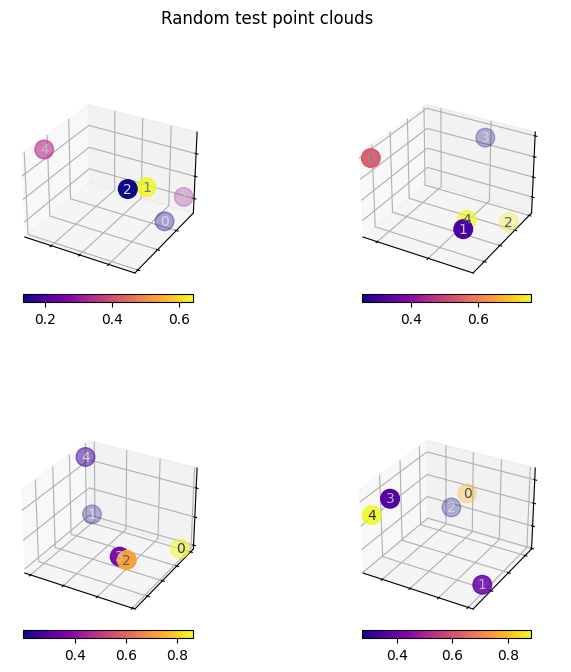

In [5]:
def to_perceived_brightness(rgb: np.ndarray) -> np.ndarray:
    """
    Auxiliary function, useful for choosing label colors
    with good visibility
    """
    r, g, b = rgb
    return 0.1 * r + 0.8 * g + 0.1


def plot_point_cloud_3d(
    fig: mpl.figure.Figure,
    ax_pos: int,
    color: np.ndarray,
    pos: np.ndarray,
    cmap: str = "plasma",
    point_size: float = 180.0,
    label_axes: bool = False,
    annotate_points: bool = True,
    remove_axes_ticks: bool = True,
    cbar_label: str = "",
) -> mpl.axis.Axis:
    """Visualize colored 3D point clouds.

    Parameters
    ----------
    fig : mpl.figure.Figure
        The figure for which a new axis object is added for plotting
    ax_pos : int
        Three-digit integer specifying axis layout and position
        (see docs for `mpl.figure.Figure.add_subplot`)
    color : np.ndarray
        The point colors as a float array of shape `(N,)`
    pos : np.ndarray
        The point xyz-coordinates as an array
    cmap : str, optional
        String identifier for a matplotlib colormap.
        Is used to map the values in `color` to rgb colors.
        , by default "plasma"
    point_size : float, optional
        The size of plotted points, by default 180.0
    label_axes : bool, optional
        whether to label x,y and z axes by default False
    annotate_points : bool, optional
        whether to label points with their index, by default True
    cbar_label : str, optional
        label for the colorbar, by default ""

    Returns
    -------
    mpl.axis.Axis
        The new axis object for the 3D point cloud plot.
    """
    # cmap = mpl.cm.get_cmap(cmap)
    cmap = mpl.colormaps[cmap]
    ax = fig.add_subplot(ax_pos, projection="3d")
    x, y, z = pos
    if remove_axes_ticks:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])
    if label_axes:
        ax.set_xlabel("$x$ coordinate")
        ax.set_ylabel("$y$ coordinate")
        ax.set_zlabel("$z$ coordinate")
    sc = ax.scatter(x, y, z, c=color, cmap=cmap, s=point_size)
    plt.colorbar(sc, location="bottom", shrink=0.6, anchor=(0.5, 2), label=cbar_label)
    if annotate_points:
        _colors = sc.cmap(color)
        rgb = _colors[:, :3].transpose()
        brightness = to_perceived_brightness(rgb)
        for i, (xi, yi, zi, li) in enumerate(zip(x, y, z, brightness)):
            ax.text(xi, yi, zi, str(i), None, color=[1 - li] * 3, ha="center", va="center")
    return ax


# testing
fig = plt.figure(figsize=(8, 8))

for ax_pos in [221, 222, 223, 224]:
    pos = np.random.rand(3, 5)
    color = np.random.rand(5)
    plot_point_cloud_3d(fig, ax_pos, color, pos)

fig.suptitle("Random test point clouds")
# fig.tight_layout()

In [6]:
def plot_model_input(data: Data, fig: mpl.figure.Figure, ax_pos: int) -> mpl.axis.Axis:
    """
    Plots 3D point cloud model input represented by a torch geometric
    `Data` object. Use atomic numbers as colors.

    Parameters
    ----------
    data : Data
        The 3D point cloud. Must have atomic numbers `z` and 2D coordinates `pos`
        properties that are not `None`.
    fig: mpl.figure.Figure
        The maptlotlib figure to plot on.
    ax_pos:
        Three-digit integer specifying axis layout and position
        (see docs for `mpl.figure.Figure.add_subplot`).

    Returns
    -------
    mpl.axis.Axis
        The newly created axis object.
    """
    color, pos = data.z, data.pos
    color = color.flatten().detach().numpy()
    pos = pos.T.detach().numpy()
    return plot_point_cloud_3d(fig, ax_pos, color, pos, cbar_label="Atomic number")


def plot_model_embedding(
    data: Data, model: Callable[[Data], Tensor], fig: mpl.figure.Figure, ax_pos: int
) -> mpl.axis.Axis:
    """
    Same as `plot_model_input` but instead of node features as color,
    first apply a GNN model to obtain colors from node embeddings.

    Parameters
    ----------
    data : Data
        the model input. Must have 3D coordinates `pos`
        an atomic number `z` properties that are not `None`.
    model : Callable[[Data], Tensor]
        the model must take Data objects as input and return node embeddings
        as a Tensor output.
    fig: mpl.figure.Figure
        The maptlotlib figure to plot on.
    ax_pos:
        Three-digit integer specifying axis layout and position
        (see docs for `mpl.figure.Figure.add_subplot`).

    Returns
    -------
    mpl.axis.Axis
        The newly created axis object.
    """
    x = model(data)
    pos = data.pos
    color = x.flatten().detach().numpy()
    pos = pos.T.detach().numpy()
    return plot_point_cloud_3d(fig, ax_pos, color, pos, cbar_label="Atom embedding (1D)")

### 设置并检查 QM9 数据集


#### 预处理

首先，我们必须下载和解压原始数据（如果尚未完成）。如上所述，我们将使用整个数据集的子集以加快训练速度。我们还将过滤掉我们不需要的特定目标。无关的分子将被丢弃。


In [7]:
def num_heavy_atoms(qm9_data: Data) -> int:
    """Count the number of heavy atoms in a torch geometric
    Data object.

    Parameters
    ----------
    qm9_data : Data
        A pytorch geometric qm9 data object representing a small molecule
         where atomic numbers are stored in a
        tensor-valued attribute `qm9_data.z`

    Returns
    -------
    int
        The number of heavy atoms in the molecule.
    """
    # every atom with atomic number other than 1 is heavy
    return (qm9_data.z != 1).sum()


def complete_edge_index(n: int) -> LongTensor:
    """
    Constructs a complete edge index.

    NOTE: representing complete graphs
    with sparse edge tensors is arguably a bad idea
    due to performance reasons, but for this tutorial it'll do.

    Parameters
    ----------
    n : int
        the number of nodes in the graph.

    Returns
    -------
    LongTensor
        A PyTorch `edge_index` represents a complete graph with n nodes,
        without self-loops. Shape (2, n).
    """
    # filter removes self loops
    edges = list(filter(lambda e: e[0] != e[1], product(range(n), range(n))))
    return torch.tensor(edges, dtype=torch.long).T


def add_complete_graph_edge_index(data: Data) -> Data:
    """
    On top of any edge information already there,
    add a second edge index that represents
    the complete graph corresponding to a  given
    torch geometric data object

    Parameters
    ----------
    data : Data
        The torch geometric data object.

    Returns
    -------
    Data
        The torch geometric `Data` object with a new
        attribute `complete_edge_index` as described above.
    """
    data.complete_edge_index = complete_edge_index(data.num_nodes)
    return data


#
dataset = QM9(
    DATA,
    # Filter out molecules with more than 8 heavy atoms
    pre_filter=lambda data: num_heavy_atoms(data) < 9,
    # implement point cloud adjacency as a complete graph
    pre_transform=add_complete_graph_edge_index,
)

print(f"Num. examples in QM9 restricted to molecules with at most 8 heavy atoms: {len(dataset)}")

Num. examples in QM9 restricted to molecules with at most 8 heavy atoms: 21800


**注意**：首次执行上述单元格会首先下载然后处理原始数据，这**可能需要一些时间**！QM9 数据集的下载量约为 100 MB（原始数据为 2.9 GB）。


对我们刚刚创建的数据集进行索引会返回一个表示一个分子图/点云的 PyTorch Geometric `Data` 对象。每个分子在数据集中都有唯一的标识符（QM9 中的名称）。


In [8]:
data = dataset[0]
# This displays all named data attributes, and their shapes (in the case of tensors), or values (in the case of other data).
data

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5], complete_edge_index=[2, 20])

对于索引 0（名称为 `gdb_1`），应该是 CH4 分子。我们可以通过查看 `z` 张量中存储的原子序数来验证这一点：8 号元素是氧，1 号元素是氢，6 号元素是碳等。


In [9]:
data.z

tensor([6, 1, 1, 1, 1])

对于具有 $N$ 个原子和 $M$ 个（共价）键的分子，数据对象还包含形状如下的命名张量：

| 字段 | 形状 | 内容 |
|------|------|------|
| `z` | $(N,)$ | 原子序数（整数） |
| `pos` | $(N, 3)$ | 3D 坐标 |
| `y` | $(19,)$ | 目标（我们使用索引 6 处的条目表示空间范围） |
| `edge_index` | $(2, M)$ | 分子图的边列表格式的邻接矩阵 |

在后续中，我们感兴趣的是根据其 3D 坐标和节点特征来预测分子的空间范围。在我们的模型中，我们**不**使用边索引（即分子图），但从数据集中仍然可以使用它。


In [10]:
data.pos.round(decimals=2)

tensor([[-0.0100,  1.0900,  0.0100],
        [ 0.0000, -0.0100,  0.0000],
        [ 1.0100,  1.4600,  0.0000],
        [-0.5400,  1.4500, -0.8800],
        [-0.5200,  1.4400,  0.9100]])

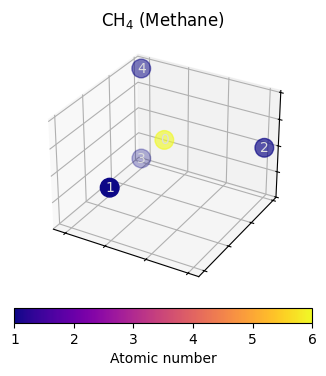

In [11]:
fig = plt.figure()
ax = plot_model_input(data, fig, 111)
_ = ax.set_title("CH$_4$ (Methane)")

#### 原子序数分布和点云大小

在深入实现之前，让我们看看数据集中的分子是什么样子的。首先，我们检查数据集中原子序数的分布。


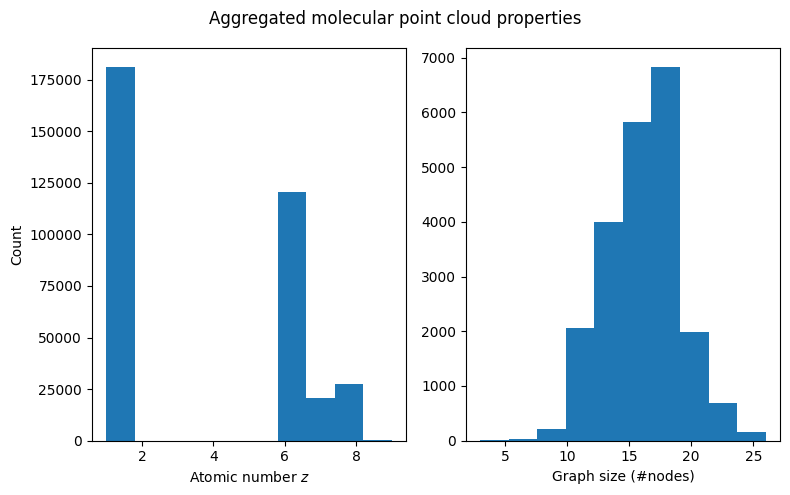

In [12]:
fig, (ax_atoms, ax_graph_size) = plt.subplots(1, 2, figsize=(8, 5))

# ax_atoms.hist(dataset.data.z[dataset.data.z != 1])
ax_atoms.hist(dataset.z)  # previously dataset.data.z
ax_atoms.set_xlabel("Atomic number $z$")
ax_atoms.set_ylabel("Count")
num_nodes = [dataset[i].num_nodes for i in range(len(dataset))]
ax_graph_size.hist(num_nodes)
ax_graph_size.set_xlabel("Graph size (#nodes)")
fig.suptitle("Aggregated molecular point cloud properties")
fig.tight_layout()

我们可以看到，虽然氟原子（编号 9）出现在数据中，但其代表性严重不足（$z=9$ 处的条形几乎看不见）。当我们拆分数据时，我们必须牢记这一点，因为大多数数据拆分方法只考虑目标值 $y$，而不考虑 **z** 的分布。如果数据拆分严重不平衡，$\hat{z}=9$ 的分子可能只出现在测试集中，这将导致模型在面对这种分子时表现不佳。

首先，让我们创建一个按原子序数拆分的数据集。

**注意**：对于这种特殊的数据拆分，我们利用 `z`（原子序数）可用的事实。然而，原子序数在分子之间通常是可变的，不是像典型的监督学习目标那样是一个全局标签：每个分子可以有数量不等的原子，这些原子可能具有不同的原子序数。这种高信息量的结构在标准的临床预测问题中并不典型，但在分子建模中却是常态。


#### 数据拆分，回归目标电子空间范围的分布

现在，让我们按原子序数拆分数据：所有含有氟原子的分子进入测试集和验证集；所有不含氟的分子进入训练集。这是为了展示当数据拆分产生分布外测试集时会发生什么。这通常发生在低资源设置或探索性任务中。然而，在现实世界中，这样的拆分更为典型：我们几乎总是希望预测与我们已有的分子类型不同的分子性质。

对于训练/验证/测试，我们按 70/15/15 的比例拆分。


In [13]:
class QM9DataModule:
    def __init__(
        self,
        train_ratio: float = 0.8,
        val_ratio: float = 0.1,
        test_ratio: float = 0.1,
        target_idx: int = 5,
        seed: float = 420,
    ) -> None:
        """Encapsulates everything related to the dataset

        Parameters
        ----------
        train_ratio : float, optional
            fraction of data used for training, by default 0.8
        val_ratio : float, optional
            fraction of data used for validation, by default 0.1
        test_ratio : float, optional
            fraction of data used for testing, by default 0.1
        target_idx : int, optional
            index of the target (see torch geometric docs), by default 5 (electronic spatial extent)
            (https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html?highlight=qm9#torch_geometric.datasets.QM9)
        seed : float, optional
            random seed for data split, by default 420
        """
        assert sum([train_ratio, val_ratio, test_ratio]) == 1
        self.target_idx = target_idx
        self.num_examples = len(self.dataset())
        rng = np.random.default_rng(seed)
        self.shuffled_index = rng.permutation(self.num_examples)
        self.train_split = self.shuffled_index[: int(self.num_examples * train_ratio)]
        self.val_split = self.shuffled_index[
            int(self.num_examples * train_ratio) : int(
                self.num_examples * (train_ratio + val_ratio)
            )
        ]
        self.test_split = self.shuffled_index[
            int(self.num_examples * (train_ratio + val_ratio)) : self.num_examples
        ]

    def dataset(self, transform=None) -> QM9:
        dataset = QM9(
            DATA,
            pre_filter=lambda data: num_heavy_atoms(data) < 9,
            pre_transform=add_complete_graph_edge_index,
        )
        dataset.data.y = dataset.data.y[:, self.target_idx].view(-1, 1)
        return dataset

    def loader(self, split, **loader_kwargs) -> DataLoader:
        dataset = self.dataset()[split]
        return DataLoader(dataset, **loader_kwargs)

    def train_loader(self, **loader_kwargs) -> DataLoader:
        return self.loader(self.train_split, shuffle=True, **loader_kwargs)

    def val_loader(self, **loader_kwargs) -> DataLoader:
        return self.loader(self.val_split, shuffle=False, **loader_kwargs)

    def test_loader(self, **loader_kwargs) -> DataLoader:
        return self.loader(self.test_split, shuffle=False, **loader_kwargs)

现在我们可以轻松地绘制数据拆分中的目标分布。


<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_266792/2426728866.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel("Electronic spatial extent $\langle R^2 \\rangle$")
/tmp/ipykernel_266792/725946626.py:47: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  dataset.data.y = dataset.data.y[:, self.target_idx].view(-1, 1)


Text(0.5, 0.98, 'Random data split - target distribution')

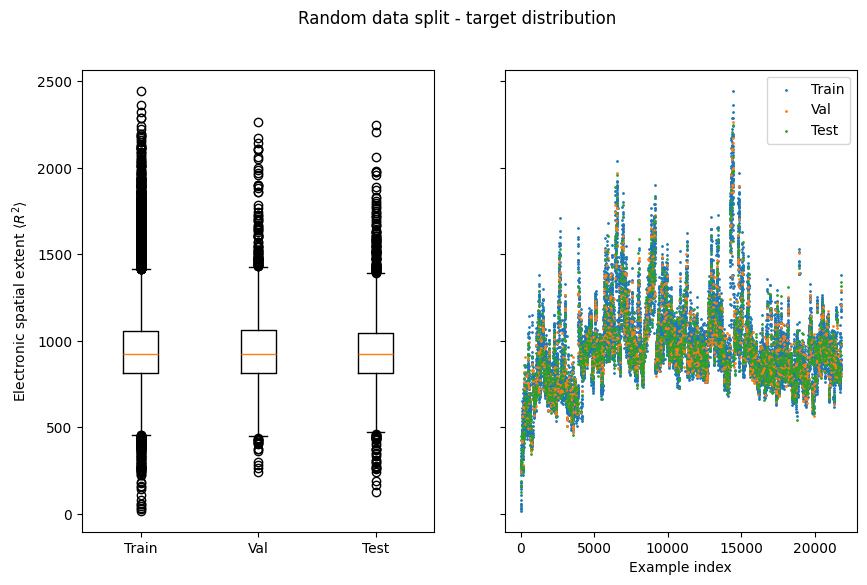

In [14]:
data_module = QM9DataModule()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
target = (
    data_module.dataset().y.flatten().numpy()
)  # (previously) target = data_module.dataset().data.y.flatten().numpy()
ax1.boxplot(
    [
        target[data_module.train_split],
        target[data_module.val_split],
        target[data_module.test_split],
    ]
)
ax1.set_xticklabels(["Train", "Val", "Test"])
ax1.set_ylabel("Electronic spatial extent $\langle R^2 \\rangle$")

for label, split in {
    "Train": data_module.train_split,
    "Val": data_module.val_split,
    "Test": data_module.test_split,
}.items():
    ax2.scatter(split, target[split], label=label, s=1)

ax2.set_xlabel("Example index")
ax2.legend()
fig.suptitle("Random data split - target distribution")

你应该能观察到随机拆分通常是非常同质的，这意味着在这些条件下测量泛化能力很容易（但不太有信息量）。另一方面，按原子序数拆分会创建非同质的数据拆分。测量这种条件（也称为分布外泛化）下的泛化能力要困难得多，但也更有信息量。

在训练过程中，我们使用**验证集**进行早停和模型选择。**测试集**仅用于评估最终的泛化能力，在训练期间不会以任何方式使用。


### 模型实现


#### 简单的"朴素欧几里得"GNN

我们将实现一个非常简单的 GNN，它使用 3D 坐标作为额外的节点特征。这个模型将是我们在实践部分实现的第二个模型 EGNN 的对照。

该模型是一个简单的消息传递 GNN，使用与 **T035** 中`GCNConv`层类似的思想。它在这里被保留为一个简单的参考，以强调标准 GNN 的局限性。

我们已经从理论部分了解到，在节点特征中包含坐标可能会因为等变性问题导致非最优学习。这个模型将作为对照实验。如果等变性实际上无关紧要，那么两个模型应该表现相似。如果在坐标中使用距离比使用原始坐标更好，那么 EGNN 应该优于简单的 GNN。在评估部分，我们将找出答案。


In [15]:
class NaiveEuclideanGNN(nn.Module):
    def __init__(
        self,
        hidden_channels: int,
        num_layers: int,
        num_spatial_dims: int,
        final_embedding_size: Optional[int] = None,
        act: nn.Module = nn.ReLU(),
    ) -> None:
        super().__init__()
        # NOTE nn.Embedding acts like a lookup table.
        # Here we use it to store each atomic number in [0,100]
        # a learnable, fixed-size vector representation
        self.f_initial_embed = nn.Embedding(100, hidden_channels)
        self.f_pos_embed = nn.Linear(num_spatial_dims, hidden_channels)
        self.f_combine = nn.Sequential(nn.Linear(2 * hidden_channels, hidden_channels), act)

        if final_embedding_size is None:
            final_embedding_size = hidden_channels

        # Graph isomorphism network as main GNN
        # (see Talktorial 034)
        # takes care of message passing and
        # Learning node-level embeddings
        self.gnn = geom_nn.models.GIN(
            in_channels=hidden_channels,
            hidden_channels=hidden_channels,
            out_channels=final_embedding_size,
            num_layers=num_layers,
            act=act,
        )

        # modules required for aggregating node embeddings
        # into graph embeddings and making graph-level predictions
        self.aggregation = geom_nn.aggr.SumAggregation()
        self.f_predict = nn.Sequential(
            nn.Linear(final_embedding_size, final_embedding_size),
            act,
            nn.Linear(final_embedding_size, 1),
        )

    def encode(self, data: Data) -> Tensor:
        # initial atomic number embedding and embedding od positional information
        atom_embedding = self.f_initial_embed(data.z)
        pos_embedding = self.f_pos_embed(data.pos)

        # treat both as plain node-level features and combine into initial node-level
        # embedddings
        initial_node_embed = self.f_combine(torch.cat((atom_embedding, pos_embedding), dim=-1))

        # message passing
        # NOTE in contrast to the EGNN implemented later, this model does use bond information
        # i.e., data.egde_index stems from the bond adjacency matrix
        node_embed = self.gnn(initial_node_embed, data.edge_index)
        return node_embed

    def forward(self, data: Data) -> Tensor:
        node_embed = self.encode(data)
        aggr = self.aggregation(node_embed, data.batch)
        return self.f_predict(aggr)

#### 示例：简单 GNN 不是 E(3)-不变的

让我们测试一个未训练的简单 GNN，通过比较原始数据与旋转版本上的预测来验证它是否违反等变性。我们还绘制了坐标作为参考。


In [16]:
# use rotations along z-axis as demo e(3) transformation
def rotation_matrix_z(theta: float) -> Tensor:
    """Generates a rotation matrix and returns
    a corresponing tensor. The rotation is about the $z$-axis.
    (https://en.wikipedia.org/wiki/Rotation_matrix)

    Parameters
    ----------
    theta : float
        the angle of rotation.

    Returns
    -------
    Tensor
        the rotation matrix as float tensor.
    """
    return torch.tensor(
        [
            [math.cos(theta), -math.sin(theta), 0],
            [math.sin(theta), math.cos(theta), 0],
            [0, 0, 1],
        ]
    )

**注意**：你可能需要多次运行下面的单元格，才能找到一个可以轻松观察到非不变性的模型初始化。如果你已经看到了不变性，请重新运行单元格（这将创建一个新的随机模型）并重新扫描。

如果参数初始化不幸地导致模型对所有输入都输出恒定的（可能为零）输出，就会出现这种非预期的"不变性"。


/tmp/ipykernel_266792/2912899843.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


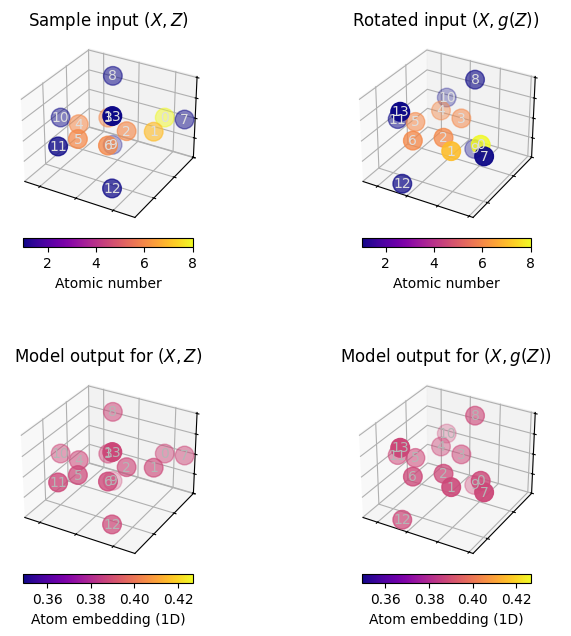

In [17]:
# Some data points from qm9
sample_data = dataset[800].clone()

# apply an E(3) transformation
rotated_sample_data = sample_data.clone()
rotated_sample_data.pos = rotated_sample_data.pos @ rotation_matrix_z(45)

# initialize a model with 2 hidden layers, 32 hidden channels,
# that outputs 1-dimensional node embeddings
model = NaiveEuclideanGNN(
    hidden_channels=32,
    num_layers=2,
    num_spatial_dims=3,
    final_embedding_size=1,
)

# make a plot that demonstrates non-equivariance
# fig, axes = plt.subplots(2, 2, figsize=(8,8), sharex=True, sharey=True)
fig = plt.figure(figsize=(8, 8))

ax1 = plot_model_input(sample_data, fig, 221)
ax1.set_title("Sample input $(X, Z)$")

ax2 = plot_model_input(rotated_sample_data, fig, 222)
ax2.set_title("Rotated input $(X, g(Z))$")

ax3 = plot_model_embedding(sample_data, model.encode, fig, 223)
ax3.set_title("Model output for $(X, Z)$")

ax4 = plot_model_embedding(rotated_sample_data, model.encode, fig, 224)
ax4.set_title("Model output for $(X, g(Z))$")
fig.tight_layout()

多次执行上述单元格后，我们可以观察到旋转分子可能会在多次运行中*显著*改变原子的嵌入。从原则上来讲，这应该不会发生。因此，我们的简单 GNN 不是 E(3)-不变的。


#### EGNN 模型

我们现在基于理论部分概述的原理实现一个 E(n)-不变 GNN。

该实现直接遵循 [Satorras et al.](https://arxiv.org/abs/2102.09844) 的 EGNN 论文。详细信息请参阅该论文。


我们现在基于理论部分概述的原理实现一个 E(n)-不变 GNN。

该实现直接遵循 [Satorras et al.](https://arxiv.org/abs/2102.09844) 的 EGNN 论文。详细信息请参阅该论文。


In [18]:
class EquivariantMPLayer(nn.Module):
    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        act: nn.Module,
    ) -> None:
        super().__init__()
        self.act = act
        self.residual_proj = nn.Linear(in_channels, hidden_channels, bias=False)

        # Messages will consist of two (source and target) node embeddings and a scalar distance
        message_input_size = 2 * in_channels + 1

        # equation (3) "phi_l" NN
        self.message_mlp = nn.Sequential(
            nn.Linear(message_input_size, hidden_channels),
            act,
        )
        # equation (4) "psi_l" NN
        self.node_update_mlp = nn.Sequential(
            nn.Linear(in_channels + hidden_channels, hidden_channels),
            act,
        )

    def node_message_function(
        self,
        source_node_embed: Tensor,  # h_i
        target_node_embed: Tensor,  # h_j
        node_dist: Tensor,  # d_ij
    ) -> Tensor:
        # implements equation (3)
        message_repr = torch.cat((source_node_embed, target_node_embed, node_dist), dim=-1)
        return self.message_mlp(message_repr)

    def compute_distances(self, node_pos: Tensor, edge_index: LongTensor) -> Tensor:
        row, col = edge_index
        xi, xj = node_pos[row], node_pos[col]
        # relative squared distance
        # implements equation (2) ||X_i - X_j||^2
        rsdist = (xi - xj).pow(2).sum(1, keepdim=True)
        return rsdist

    def forward(
        self,
        node_embed: Tensor,
        node_pos: Tensor,
        edge_index: Tensor,
    ) -> Tensor:
        row, col = edge_index
        dist = self.compute_distances(node_pos, edge_index)

        # compute messages "m_ij" from  equation (3)
        node_messages = self.node_message_function(node_embed[row], node_embed[col], dist)

        # message sum aggregation in equation (4)
        aggr_node_messages = scatter(node_messages, col, dim=0, reduce="sum")

        # compute new node embeddings "h_i^{l+1}"
        # (implements rest of equation (4))
        new_node_embed = self.residual_proj(node_embed) + self.node_update_mlp(
            torch.cat((node_embed, aggr_node_messages), dim=-1)
        )

        return new_node_embed


class EquivariantGNN(nn.Module):
    def __init__(
        self,
        hidden_channels: int,
        final_embedding_size: Optional[int] = None,
        target_size: int = 1,
        num_mp_layers: int = 2,
    ) -> None:
        super().__init__()
        if final_embedding_size is None:
            final_embedding_size = hidden_channels

        # non-linear activation func.
        # usually configurable, here we just use Relu for simplicity
        self.act = nn.ReLU()

        # equation (1) "psi_0"
        self.f_initial_embed = nn.Embedding(100, hidden_channels)

        # create stack of message passing layers
        self.message_passing_layers = nn.ModuleList()
        channels = [hidden_channels] * (num_mp_layers) + [final_embedding_size]
        for d_in, d_out in zip(channels[:-1], channels[1:]):
            layer = EquivariantMPLayer(d_in, d_out, self.act)
            self.message_passing_layers.append(layer)

        # modules required for readout of a graph-level
        # representation and graph-level property prediction
        self.aggregation = SumAggregation()
        self.f_predict = nn.Sequential(
            nn.Linear(final_embedding_size, final_embedding_size),
            self.act,
            nn.Linear(final_embedding_size, target_size),
        )

    def encode(self, data: Data) -> Tensor:
        # theory, equation (1)
        node_embed = self.f_initial_embed(data.z)
        # message passing
        # theory, equation (3-4)
        for mp_layer in self.message_passing_layers:
            # NOTE here we use the complete edge index defined by the transform earlier on
            # to implement the sum over $j \neq i$ in equation (4)
            node_embed = mp_layer(node_embed, data.pos, data.complete_edge_index)
        return node_embed

    def _predict(self, node_embed, batch_index) -> Tensor:
        aggr = self.aggregation(node_embed, batch_index)
        return self.f_predict(aggr)

    def forward(self, data: Data) -> Tensor:
        node_embed = self.encode(data)
        pred = self._predict(node_embed, data.batch)
        return pred

#### 示例：我们的 EGNN 是 E(3)-不变的

现在让我们为 EGNN 重复不变性测试（请注意，EGNN 的输出是分子嵌入，而不是预测）。我们使用（随机初始化的）EGNN 生成嵌入，并检查旋转前后的嵌入是否相同。


In [19]:
model = EquivariantGNN(hidden_channels=32, final_embedding_size=1, num_mp_layers=2)

Text(0.5, 0.92, 'Model output for $(X, g(Z))$')

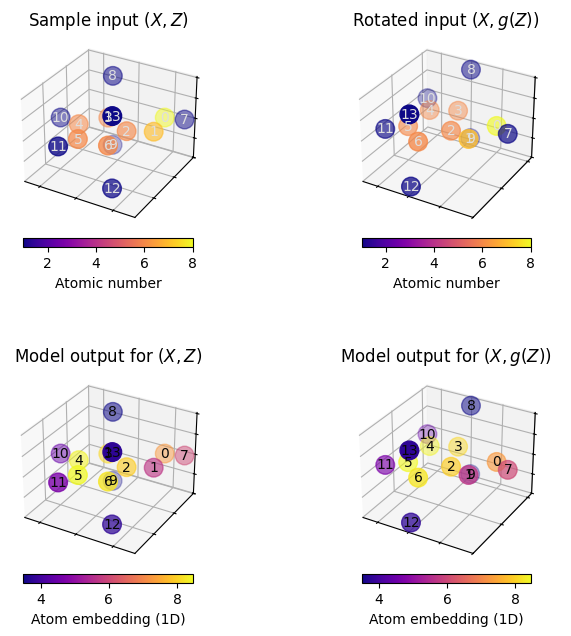

In [20]:
# Some data points from qm9
sample_data = dataset[800].clone()

# apply E(3) transformation
rotated_sample_data = sample_data.clone()
rotated_sample_data.pos = rotated_sample_data.pos @ rotation_matrix_z(120)

fig = plt.figure(figsize=(8, 8))

ax1 = plot_model_input(sample_data, fig, 221)
ax1.set_title("Sample input $(X, Z)$")

ax2 = plot_model_input(rotated_sample_data, fig, 222)
ax2.set_title("Rotated input $(X, g(Z))$")

ax3 = plot_model_embedding(sample_data, model.encode, fig, 223)
ax3.set_title("Model output for $(X, Z)$")

ax4 = plot_model_embedding(rotated_sample_data, model.encode, fig, 224)
ax4.set_title("Model output for $(X, g(Z))$")
# fig.tight_layout()

你可以随意多次执行上述单元格，无论你选择什么输入，原子嵌入在经过 E(3)-变换后总是相同的。因此，我们的 E(3)-不变模型是有效的。

如果你好奇，你也可以在 EGNN 中通过将归一化距离恢复为原始 3D 坐标并重新运行不变性测试来验证这一点。在对原始坐标进行操作时，EGNN 将不再是不变的。


### 训练和评估

我们在两个不同的数据拆分上训练模型：1) 随机拆分和 2) 按原子序数拆分。因此，我们有四种条件：

- 简单 GNN + 随机拆分
- 简单 GNN + 按原子序数拆分
- EGNN + 随机拆分
- EGNN + 按原子序数拆分

在为期 30 个 epoch 的训练期间，我们在验证集上跟踪平均绝对误差（MAE）。一旦验证 MAE 在 10 个 epoch 内没有改善，我们就停止训练（早停）。


In [21]:
# We will be using mean absolute error
# as a metric for validation and testing
def total_absolute_error(pred: Tensor, target: Tensor, batch_dim: int = 0) -> Tensor:
    """Total absolute error, i.e. sums over batch dimension.

    Parameters
    ----------
    pred : Tensor
        batch of model predictions
    target : Tensor
        batch of ground truth / target values
    batch_dim : int, optional
        dimension that indexes batch elements, by default 0

    Returns
    -------
    Tensor
        total absolute error
    """
    return (pred - target).abs().sum(batch_dim)

In [22]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: Callable[[Tensor, Tensor], Tensor],
    pbar: Optional[Any] = None,
    optim: Optional[torch.optim.Optimizer] = None,
):
    """Run a single epoch.

    Parameters
    ----------
    model : nn.Module
        the NN used for regression
    loader : DataLoader
        an iterable over data batches
    criterion : Callable[[Tensor, Tensor], Tensor]
        a criterion (loss) that is optimized
    pbar : Optional[Any], optional
        a tqdm progress bar, by default None
    optim : Optional[torch.optim.Optimizer], optional
        a optimizer that is optimizing the criterion, by default None
    """

    def step(
        data_batch: Data,
    ) -> Tuple[float, float]:
        """Perform a single train/val step on a data batch.

        Parameters
        ----------
        data_batch : Data

        Returns
        -------
        Tuple[float, float]
            Loss (mean squared error) and validation critierion (absolute error).
        """
        pred = model.forward(data_batch)
        target = data_batch.y
        loss = criterion(pred, target)
        if optim is not None:
            optim.zero_grad()
            loss.backward()
            optim.step()
        return loss.detach().item(), total_absolute_error(pred.detach(), target.detach())

    if optim is not None:
        model.train()
        # This enables pytorch autodiff s.t. we can compute gradients
        model.requires_grad_(True)
    else:
        model.eval()
        # disable autodiff: when evaluating we do not need to track gradients
        model.requires_grad_(False)

    total_loss = 0
    total_mae = 0
    for data in loader:
        loss, mae = step(data)
        total_loss += loss * data.num_graphs
        total_mae += mae
        if pbar is not None:
            pbar.update(1)

    return total_loss / len(loader.dataset), total_mae / len(loader.dataset)


def train_model(
    data_module: QM9DataModule,
    model: nn.Module,
    num_epochs: int = 30,
    lr: float = 3e-4,
    batch_size: int = 32,
    weight_decay: float = 1e-8,
    best_model_path: Path = DATA.joinpath("trained_model.pth"),
) -> Dict[str, Any]:
    """Takes data and model as input and runs training, collecting additional validation metrics
    while doing so.

    Parameters
    ----------
    data_module : QM9DataModule
        a data module as defined earlier
    model : nn.Module
        a gnn model
    num_epochs : int, optional
        number of epochs to train for, by default 30
    lr : float, optional
        "learning rate": optimizer SGD step size, by default 3e-4
    batch_size : int, optional
        number of examples used for one training step, by default 32
    weight_decay : float, optional
        L2 regularization parameter, by default 1e-8
    best_model_path : Path, optional
        path where the model weights with lowest val. error should be stored
        , by default DATA.joinpath("trained_model.pth")

    Returns
    -------
    Dict[str, Any]
        a training result, ie statistics and info about the model
    """
    # create data loaders
    train_loader = data_module.train_loader(batch_size=batch_size)
    val_loader = data_module.val_loader(batch_size=batch_size)

    # setup optimizer and loss
    optim = torch.optim.Adam(model.parameters(), lr, weight_decay=1e-8)
    loss_fn = nn.MSELoss()

    # keep track of the epoch with the best validation mae
    # st we can save the "best" model weights
    best_val_mae = float("inf")

    # Statistics that will be plotted later on
    # and model info
    result = {
        "model": model,
        "path_to_best_model": best_model_path,
        "train_loss": np.full(num_epochs, float("nan")),
        "val_loss": np.full(num_epochs, float("nan")),
        "train_mae": np.full(num_epochs, float("nan")),
        "val_mae": np.full(num_epochs, float("nan")),
    }

    # Auxiliary functions for updating and reporting
    # Training progress statistics
    def update_statistics(i_epoch: int, **kwargs: float):
        for key, value in kwargs.items():
            result[key][i_epoch] = value

    def desc(i_epoch: int) -> str:
        return " | ".join(
            [f"Epoch {i_epoch + 1:3d} / {num_epochs}"]
            + [
                f"{key}: {value[i_epoch]:8.2f}"
                for key, value in result.items()
                if isinstance(value, np.ndarray)
            ]
        )

    # main training loop
    for i_epoch in range(0, num_epochs):
        progress_bar = tqdm(total=len(train_loader) + len(val_loader))
        try:
            # tqdm for reporting progress
            progress_bar.set_description(desc(i_epoch))

            # training epoch
            train_loss, train_mae = run_epoch(model, train_loader, loss_fn, progress_bar, optim)
            # validation epoch
            val_loss, val_mae = run_epoch(model, val_loader, loss_fn, progress_bar)

            update_statistics(
                i_epoch,
                train_loss=train_loss,
                val_loss=val_loss,
                train_mae=train_mae,
                val_mae=val_mae,
            )

            progress_bar.set_description(desc(i_epoch))

            if val_mae < best_val_mae:
                best_val_mae = val_mae
                torch.save(model.state_dict(), best_model_path)
        finally:
            progress_bar.close()

    return result

In [23]:
@torch.no_grad()
def test_model(model: nn.Module, data_module: QM9DataModule) -> Tuple[float, Tensor, Tensor]:
    """
    Test a model.

    Parameters
    ----------
    model : nn.Module
        a trained model
    data_module : QM9DataModule
        a data module as defined earlier
        from which we'll get the test data

    Returns
    -------
    _Tuple[float, Tensor, Tensor]
        Test MAE, and model predictions & targets for further processing
    """
    test_mae = 0
    preds, targets = [], []
    loader = data_module.test_loader()
    for data in loader:
        pred = model(data)
        target = data.y
        preds.append(pred)
        targets.append(target)
        test_mae += total_absolute_error(pred, target).item()

    test_mae = test_mae / len(data_module.test_split)

    return test_mae, torch.cat(preds, dim=0), torch.cat(targets, dim=0)

#### 训练 EGNN

使用随机拆分和按原子序数拆分，在 30 个 epoch 内训练 EGNN，并跟踪验证 MAE。

**注意**：根据你机器的不同，这可能需要几分钟。如果时间太长，你可以稍后通过设置 `EPOCHS = 10` 来缩短训练时间。


In [24]:
model = EquivariantGNN(hidden_channels=64, num_mp_layers=2)

egnn_train_result = train_model(
    data_module,
    model,
    num_epochs=25,
    lr=2e-4,
    batch_size=32,
    weight_decay=1e-8,
    best_model_path=DATA.joinpath("trained_egnn.pth"),
)

/tmp/ipykernel_266792/725946626.py:47: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  dataset.data.y = dataset.data.y[:, self.target_idx].view(-1, 1)
Epoch   1 / 25 | train_loss: 66117.19 | val_loss:  6971.78 | train_mae:   151.21 | val_mae:    63.00: 100%|█| 614/614 [00:19<00:00, 32.09it/s
Epoch   2 / 25 | train_loss:  3634.91 | val_loss:  1427.47 | train_mae:    41.55 | val_mae:    25.55: 100%|█| 614/614 [00:15<00:00, 38.53it/s
Epoch   3 / 25 | train_loss:   971.71 | val_loss:   739.19 | train_mae:    21.45 | val_mae:    20.76: 100%|█| 614/614 [00:17<00:00, 35.45it/s
Epoch   4 / 25 | train_loss:   643.31 | val_loss:   833.51 | train_mae:    17.91 | val_mae:    24.32: 100%|█| 614

#### 训练简单 GNN

使用随机拆分和按原子序数拆分，在 30 个 epoch 内训练简单 GNN。


In [25]:
gcn_baseline = NaiveEuclideanGNN(64, 4, 3)

gcn_train_result = train_model(
    data_module,
    gcn_baseline,
    num_epochs=100,
    lr=3e-4,
    batch_size=32,
    best_model_path=DATA.joinpath("trained_gnn.pth"),
)

/tmp/ipykernel_266792/725946626.py:47: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  dataset.data.y = dataset.data.y[:, self.target_idx].view(-1, 1)
Epoch   1 / 100 | train_loss: 138428.00 | val_loss: 51434.91 | train_mae:   265.84 | val_mae:   174.82: 100%|█| 614/614 [00:12<00:00, 48.79it
Epoch   2 / 100 | train_loss: 45491.57 | val_loss: 38601.97 | train_mae:   159.92 | val_mae:   152.12: 100%|█| 614/614 [00:08<00:00, 75.56it/
Epoch   3 / 100 | train_loss: 32663.50 | val_loss: 26977.25 | train_mae:   137.04 | val_mae:   123.96: 100%|█| 614/614 [00:07<00:00, 80.88it/
Epoch   4 / 100 | train_loss: 21058.25 | val_loss: 19948.90 | train_mae:   108.99 | val_mae:   109.06: 100%|█| 61

#### 对比评估

首先，让我们绘制四种条件下的损失和验证 MAE。

**注意**：在第二个图中，在按原子序数拆分的条件下，简单 GNN 的验证 MAE 可能是 NaN（不可见），如果某个批次中出现了 `edge_index` 为空的情况（即分子图没有边）。这是标准 GNN 在处理非常小的分子时的一个已知问题。


In [26]:
gcn_num_params = sum(p.numel() for p in gcn_train_result["model"].parameters())
egnn_num_params = sum(p.numel() for p in egnn_train_result["model"].parameters())

for key, value in {"GCN": gcn_num_params, "EGNN": egnn_num_params}.items():
    print(f"{key} has {value} parameters")

GCN has 52417 parameters
EGNN has 51969 parameters


绘制每个 epoch 的损失和验证 MAE，我们可以观察到 EGNN 的训练过程*远*快于简单 GNN，并且达到了更低的验证误差。此外，EGNN 在随机拆分和按原子序数拆分之间的性能差异小于简单 GNN。这证实了我们的假设，即 E(3)-不变模型可以更好地泛化到分布外数据。


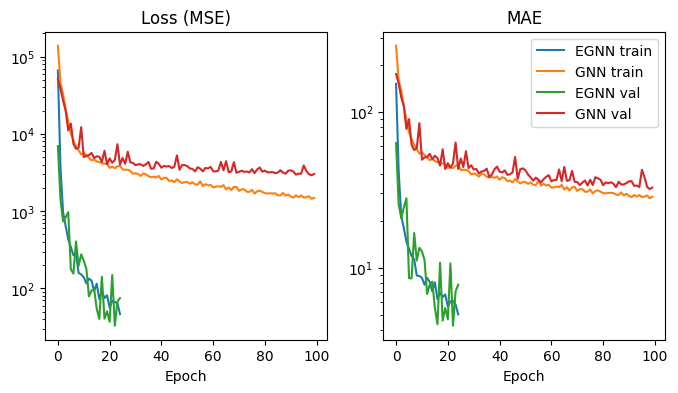

In [27]:
fig, (loss_ax, mae_ax) = plt.subplots(1, 2, figsize=(8, 4))

loss_ax.set_title("Loss (MSE)")
mae_ax.set_title("MAE")
loss_ax.set_xlabel("Epoch")
mae_ax.set_xlabel("Epoch")

for metric in ["train_loss", "val_loss", "train_mae", "val_mae"]:
    split = metric.split("_")[0]
    ax = loss_ax if "loss" in metric else mae_ax

    ax.plot(egnn_train_result[metric], label=f"EGNN {split}")
    ax.plot(gcn_train_result[metric], label=f"GNN {split}")

mae_ax.legend()
mae_ax.set_yscale("log")
loss_ax.set_yscale("log")

这种性能提升也可以在保留的测试数据中观察到。在测试时，我们选择在验证数据上平均绝对误差最低的模型。然后，我们计算这些模型在测试数据上的 MAE。


In [28]:
gcn_model = gcn_train_result["model"]
gcn_model.load_state_dict(torch.load(gcn_train_result["path_to_best_model"]))
gcn_test_mae, gcn_preds, gcn_targets = test_model(gcn_model, data_module)

egnn_model = egnn_train_result["model"]
egnn_model.load_state_dict(torch.load(egnn_train_result["path_to_best_model"]))
egnn_test_mae, egnn_preds, egnn_targets = test_model(egnn_model, data_module)

print(f"EGNN test MAE: {egnn_test_mae}")
print(f"GNN test MAE: {gcn_test_mae}")

/tmp/ipykernel_266792/725946626.py:47: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  dataset.data.y = dataset.data.y[:, self.target_idx].view(-1, 1)


EGNN test MAE: 4.340438702784547
GNN test MAE: 32.60893801067947


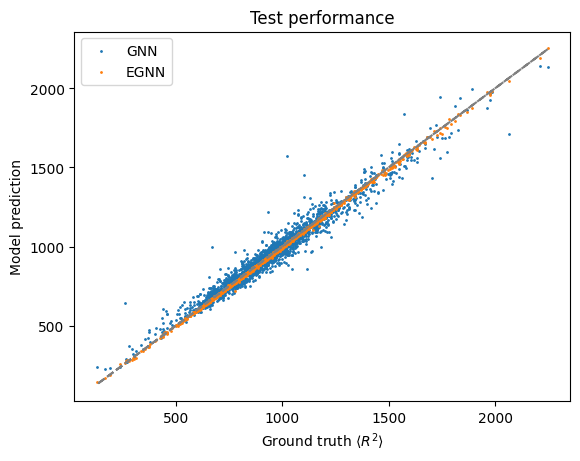

In [31]:
fig, ax = plt.subplots()
ax.plot(gcn_targets, gcn_targets, "--", color="grey")
ax.scatter(gcn_targets, gcn_preds, s=1, label="GNN")
ax.scatter(egnn_targets, egnn_preds, s=1, label="EGNN")
ax.set_ylabel("Model prediction")
ax.set_xlabel(r"Ground truth $\langle R^2 \rangle$")
ax.set_title("Test performance")
ax.legend()

这些发现支持了我们最初的假设，即 E(3)-不变模型能够比非不变模型更快地学习和更好地泛化。虽然这是一个小规模的实验，但结果与文献中的报告一致。


## 讨论

在本次教程中，我们：

*   讨论了为什么 3D 点云是分子的有用表示。
*   了解了 E(3)-不变模型背后的概念。
*   在 QM9 数据子集上实现了 E(3)-不变 GNN。
*   展示了我们的 E(3)-不变模型确实具有该特性，并且与非不变模型相比，在随机和分布外数据拆分上表现更好。

这是一个充满希望的信号，即在分子性质预测中纳入 3D 信息应该被视为标准做法。然而，挑战依然存在：

*   **性能：** 我们只训练了 30 个 epoch（且仅使用 3000 个分子）来演示概念。对于现实世界的应用，更长时间的训练和更大的数据集（例如完整的 QM9 数据集）是必不可少的。
*   **构象集合：** 我们使用每个分子的单一构象进行训练和测试。然而，分子在现实中是动态的：它们可以通过键旋转改变其构象，并且在某些情况下，只有部分构象是可观察到的。分子可以具有生物活性，即使其最低能量构象并不完全符合这种形式。对于可能需要多构象感知的构象集合，**不变性**甚至可能是有害的（ [Großmann et al.](https://openreview.net/forum?id=hm2tNDdgaFK)）。
*   **数据可用性：** 3D 坐标通常来自昂贵的实验（例如 X 射线晶体学）或计算费用高昂的模拟（例如 DFT）。对于许多分子，3D 坐标并不容易获得。然而，像 AlphaFold 这样的工具现在可以预测蛋白质的 3D 结构。对于小分子，像 [ETKDG](https://pubs.acs.org/doi/abs/10.1021/acs.jcim.0c00025) 这样的工具可以预测构象。

尽管存在这些挑战，3D 感知的深度学习模型可能会在药物发现中变得越来越重要。


## 测验

1. 为什么分子的 3D 点云表示是唯一的（每个分子一个表示），但不是完备的？反过来呢？
2. 在 GNN 的消息传递框架中融入 3D 信息时，我们面临哪些挑战？
3. 为什么不直接将坐标作为（原始）节点特征添加到标准 GNN 中？
4. 你能想到 GNN 可能不是最优的分子性质预测场景吗？
